# Progetto per l’esame di Apprendimento Automatico e Apprendimento Profondo

**Corso:** 0322509INGINF05 <br>
**Docente:** Dott.ssa Noemi Scarpato <br>
**Studente:** Matteo Personnettaz – Matr. 0322500013 <br>
**Dataset:** UCI - Bank Marketing Dataset (ID=222)

---

## Obiettivo del progetto

Il seguente notebook documenta lo sviluppo di un esperimento di classificazione supervisionata sul **Bank Marketing Dataset** del repository UCI.

L’obiettivo è prevedere se un cliente sottoscriverà o meno un deposito a termine, a partire da un insieme di variabili anagrafiche, economiche e relative alle precedenti interazioni con la banca.

Tutto il progetto è stato sviluppato seguendo le indicazioni nella traccia e comprende:
1. analisi delle feature tramite PCA;
2. implementazione di almeno tre algoritmi di classificazione;
3. calcolo delle metriche di valutazione;
4. visualizzazione di matrici di confusione e curve ROC;
5. applicazione di un approccio di spiegabilità mediante SHAP.

---

## Struttura del notebook

Il notebook è articolato nelle seguenti sezioni:

0. Importazione delle librerie
1. Caricamento del dataset e analisi preliminare dei dati
2. Preprocessing dei dati e preparazione della variabile target
3. Analisi delle feature tramite PCA e visualizzazione dei risultati
4. Implementazione e addestramento dei modelli di classificazione
5. Valutazione delle prestazioni mediante metriche quantitative
6. Analisi delle matrici di confusione e delle curve ROC
7. Interpretazione del modello mediante SHAP
8. Approfondimento: cross-validation

## 0. Importazione delle librerie

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

### 1. Caricamento del dataset e analisi preliminare dei dati

In [3]:
# 1.1 Import del DS con la libreria ucimlrepo
# DS: id=222 - Bank Marketing
bank = fetch_ucirepo(id=222)

X = bank.data.features
y = bank.data.targets

ConnectionError: Error connecting to server

In [36]:
# 1.2 Creazione del DataFrame e stampa iniziale
df = pd.concat([X, y], axis=1)
df

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN,no


In [5]:
# 1.3 Prima analisi della struttura: DIMENSIONI del DS: RIGHE, COLONNE
# df.info()
print(f"Dimensioni del dataset: {df.shape}.\n  - RIGHE: {df.shape[0]};\n  - COLONNE: {df.shape[1]};")

Dimensioni del dataset: (45211, 17).
  - RIGHE: 45211;
  - COLONNE: 17;


In [6]:
# 1.4 Tipi delle colonne
df.dtypes

age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object

In [7]:
# 1.5 Nel DataFrame creato la variabile target è rappresentata dalla colonna "y"
target_counts = df['y'].value_counts()
# Percentuale
target_ratio = df['y'].value_counts(normalize=True) * 100

#Tabella riassuntiva
target_summary = pd.DataFrame({
    'Conteggio': target_counts,
    'Percentuale (%)': target_ratio.round(2)
})

#Sorting
target_summary = target_summary.sort_index()

print("Distribuzione della variabile target:\n")
display(target_summary)

Distribuzione della variabile target:



,Conteggio,Percentuale (%)
y,,
no,39922,88.3
yes,5289,11.7


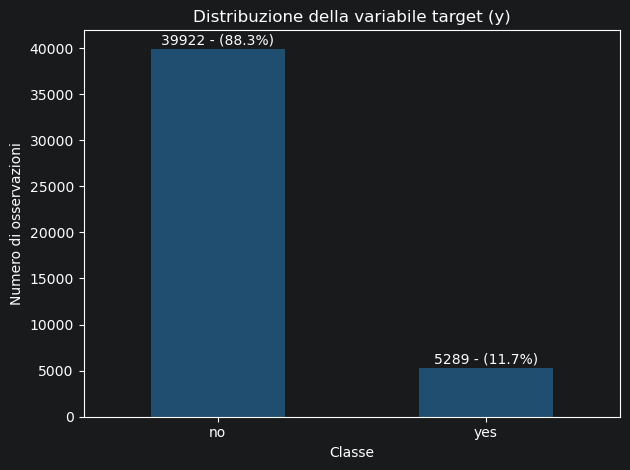

In [8]:
# 1.5.1 Grafico per relazione: FIGURA 1
plt.figure()
color = "#1f4e70"
ax = target_counts.plot(kind='bar', color=color)
plt.title("Distribuzione della variabile target (y)", fontsize=12)
plt.xlabel("Classe", fontsize=10)
plt.ylabel("Numero di osservazioni", fontsize=10)
plt.xticks(rotation=0)

total = target_counts.sum()

for i, v in enumerate(target_counts):
    perc = target_ratio.iloc[i]
    ax.text(i, v + total*0.01, f"{v} - ({perc:.1f}%)", ha='center')

plt.tight_layout()
plt.show()

## 2. Preprocessing dei dati

In [9]:
# 2.1 Separazione tra feature e target
X = df.drop(columns=['y'])
y = df['y']

print("Shape delle feature:", X.shape)
print("Shape della target:", y.shape)

Shape delle feature: (45211, 16)
Shape della target: (45211,)


In [10]:
# 2.2 Controllo preliminare delle feature prima della codifica
# Tipi di dato raggruppati
dtype_summary = X.dtypes.value_counts()
print("Distribuzione dei tipi di dato:")
print(dtype_summary.to_string())

# Colonne categoriche e numeriche
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
numeric_columns = X.select_dtypes(exclude=['object']).columns.tolist()

print(f"Numero di colonne categoriche: {len(categorical_columns)}")
print(f"Numero di colonne numeriche: {len(numeric_columns)}\n")

print("Colonne categoriche:")
for col in categorical_columns:
    print(f" - {col}")
print()

print("Colonne numeriche:")
for col in numeric_columns:
    print(f" - {col}")
print()

# Valori mancanti
missing_before = X.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("Valori mancanti per colonna:")
if not missing_before.empty:
    print(missing_before.to_string())
else:
    print("Nessun valore mancante")

Distribuzione dei tipi di dato:
object    9
int64     7
Numero di colonne categoriche: 9
Numero di colonne numeriche: 7

Colonne categoriche:
 - job
 - marital
 - education
 - default
 - housing
 - loan
 - contact
 - month
 - poutcome

Colonne numeriche:
 - age
 - balance
 - day_of_week
 - duration
 - campaign
 - pdays
 - previous

Valori mancanti per colonna:
poutcome     36959
contact      13020
education     1857
job            288


In [11]:
# 2.2.1 Controllo valori "unknown" in colonne categoriche
unknown_counts = {}

for col in categorical_columns:
    count_unknown = X[col].astype(str).str.lower().eq('unknown').sum()
    if count_unknown > 0:
        unknown_counts[col] = count_unknown

if unknown_counts:
    print(pd.Series(unknown_counts).sort_values(ascending=False).to_string())
else:
    print("Nessun valore 'unknown' rilevato")

Nessun valore 'unknown' rilevato


In [12]:
# 2.2.2 Gestione dei valori mancanti nelle feature categoriche
X_clean = X.copy()

X_clean[categorical_columns] = X_clean[categorical_columns].fillna('missing')

print("Valori mancanti dopo il riempimento delle feature categoriche:", X_clean[categorical_columns].isnull().sum().sum())
print("Valori mancanti totali X_clean:", X_clean.isnull().sum().sum())

Valori mancanti dopo il riempimento delle feature categoriche: 0
Valori mancanti totali X_clean: 0


In [13]:
# 2.3 Codifica della variabile target
y_encoded = y.map({'no': 0, 'yes': 1})

target_encoded_summary = y_encoded.value_counts().sort_index().rename(index={0: 'no -> 0', 1: 'yes -> 1'})

print("Classi originali rilevate:", list(y.unique()))
print("Numero di valori nulli dopo la codifica:", y_encoded.isnull().sum())

print("\nDistribuzione della target codificata:",target_encoded_summary.to_string())

Classi originali rilevate: ['no', 'yes']
Numero di valori nulli dopo la codifica: 0

Distribuzione della target codificata: y
no -> 0     39922
yes -> 1     5289


In [14]:
# 2.4 Encoding delle feature categoriche
X_encoded = pd.get_dummies(X_clean, drop_first=True)
# Converto in numerico su tutti per evitare di aver dei bool.
# Scelgo tipo float per rendere uniforme con le altre feauture del DS.
X_encoded = X_encoded.astype(float)

print("Valori mancanti nelle feature codificate:", X_encoded.isnull().sum().sum())
print("Shape delle feature prima dell'encoding:", X_clean.shape)
print("Shape delle feature dopo l'encoding:", X_encoded.shape)

X_encoded.head()

Valori mancanti nelle feature codificate: 0
Shape delle feature prima dell'encoding: (45211, 16)
Shape delle feature dopo l'encoding: (45211, 42)


,age,balance,day_of_week,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_missing,poutcome_other,poutcome_success
0,58.0,2143.0,5.0,261.0,1.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,44.0,29.0,5.0,151.0,1.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,33.0,2.0,5.0,76.0,1.0,-1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,47.0,1506.0,5.0,92.0,1.0,-1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,33.0,1.0,5.0,198.0,1.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [15]:
# Rifaccio i controlli e le stampe dopo l'encoding
categorical_columns = X_encoded.select_dtypes(include=['object']).columns.tolist()
numeric_columns = X_encoded.select_dtypes(exclude=['object']).columns.tolist()

print(f"Numero di colonne categoriche: {len(categorical_columns)}")
print(f"Numero di colonne numeriche: {len(numeric_columns)}\n")

print("Colonne numeriche:")
for col in numeric_columns:
    print(f" - {col}")
print()

Numero di colonne categoriche: 0
Numero di colonne numeriche: 42

Colonne numeriche:
 - age
 - balance
 - day_of_week
 - duration
 - campaign
 - pdays
 - previous
 - job_blue-collar
 - job_entrepreneur
 - job_housemaid
 - job_management
 - job_missing
 - job_retired
 - job_self-employed
 - job_services
 - job_student
 - job_technician
 - job_unemployed
 - marital_married
 - marital_single
 - education_primary
 - education_secondary
 - education_tertiary
 - default_yes
 - housing_yes
 - loan_yes
 - contact_missing
 - contact_telephone
 - month_aug
 - month_dec
 - month_feb
 - month_jan
 - month_jul
 - month_jun
 - month_mar
 - month_may
 - month_nov
 - month_oct
 - month_sep
 - poutcome_missing
 - poutcome_other
 - poutcome_success



## 3. Analisi delle feature mediante PCA e visualizzazione dei risultati

In [16]:
# 3.1 Standardizzazione delle feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [17]:
# 3.2 PCA con 2 componenti principali per visualizzazione bidimensionale
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Creazione DataFrame con le componenti principali
df_pca = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
df_pca["Target"] = y_encoded
df_pca["Classe"] = df_pca["Target"].map({
    0: "No",
    1: "Yes"
})

In [18]:
# 3.3 Varianza spiegata dalle prime due componenti principali
explained_variance = pca_2d.explained_variance_ratio_
total_explained_variance = explained_variance.sum()

print("Varianza spiegata dalle componenti principali:")
print(f" - PC1: {explained_variance[0]:.2%}")
print(f" - PC2: {explained_variance[1]:.2%}")
print(f" - Totale (PC1 + PC2): {total_explained_variance:.2%}")

Varianza spiegata dalle componenti principali:
 - PC1: 7.22%
 - PC2: 6.36%
 - Totale (PC1 + PC2): 13.59%


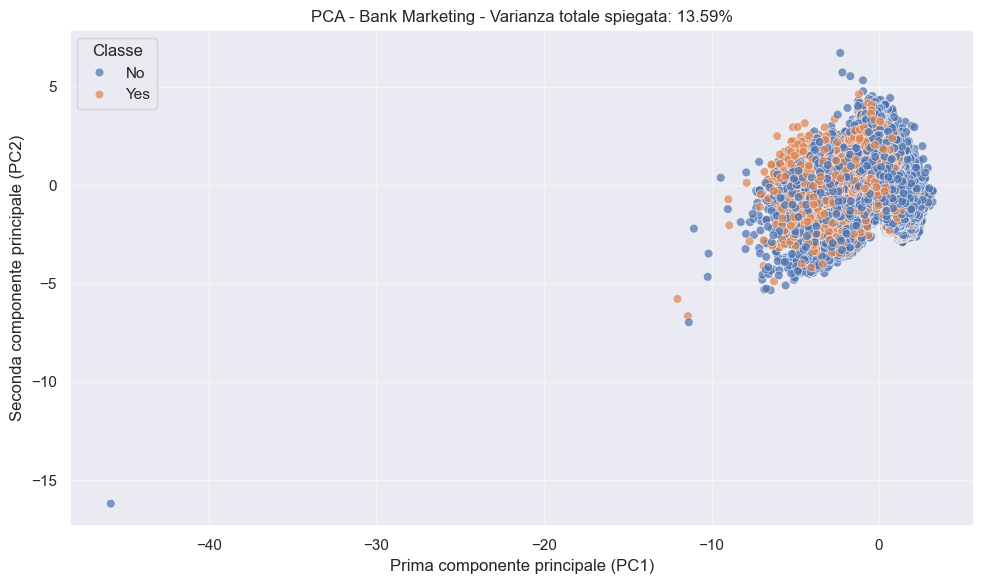

In [37]:
# 3.4 Visualizzazione della PCA
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Classe",
    s=40,
    alpha=0.7
)

plt.title(f"PCA - Bank Marketing - Varianza totale spiegata: {total_explained_variance:.2%}")
plt.xlabel("Prima componente principale (PC1)")
plt.ylabel("Seconda componente principale (PC2)")
plt.legend(title="Classe")
plt.tight_layout()
plt.show()

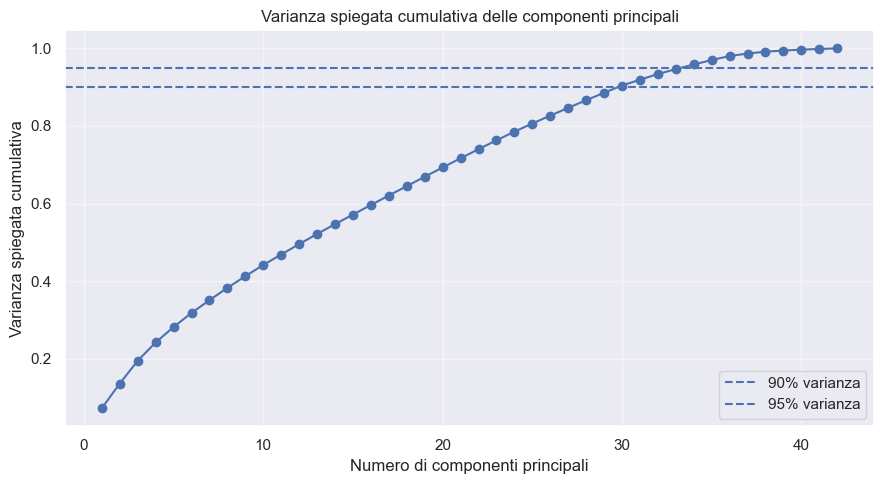

In [20]:
# 3.5 Scree plot - varianza spiegata cumulativa
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)
plt.axhline(y=0.90, linestyle='--', label='90% varianza')
plt.axhline(y=0.95, linestyle='--', label='95% varianza')

plt.title("Varianza spiegata cumulativa delle componenti principali")
plt.xlabel("Numero di componenti principali")
plt.ylabel("Varianza spiegata cumulativa")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Implementazione e addestramento dei modelli di classificazione

In [21]:
# 4.1 Suddivisione in training set e test set
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Shape training set:", X_train.shape)
print("Shape test set:", X_test.shape)
print("Distribuzione y_train:")
print(y_train.value_counts(normalize=True).sort_index().to_string())
print("\nDistribuzione y_test:")
print(y_test.value_counts(normalize=True).sort_index().to_string())

Shape training set: (36168, 42)
Shape test set: (9043, 42)
Distribuzione y_train:
y
0    0.883018
1    0.116982

Distribuzione y_test:
y
0    0.883003
1    0.116997


In [22]:
# 4.2 Standardizzazione delle feature per i modelli
scaler_model = StandardScaler()

X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

print("Standardizzazione completata.")

Standardizzazione completata.


In [23]:
# 4.3 Definizione dei classificatori
# Sono stati selezionati 3 modelli appartenenti a categorie differenti, con l'obiettivo di confrontarne il comportamento sul Bank Marketing Dataset.
# Logistic Regression viene utilizzata come modello lineare di riferimento.
# K-Nearest Neighbors classifica le osservazioni in base alla distanza tra i campioni.
# Support Vector Machine viene impiegata per individuare un confine di separazione ottimale tra le classi.

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

print("Classificatori definiti:")
for name in models.keys():
    print(f" - {name}")

Classificatori definiti:
 - Logistic Regression
 - KNN
 - SVM


In [24]:
# 4.4 Addestramento dei modelli e predizioni
# Re-inizializzo tutti i dizionari ogni volta per evitare l'overflow
trained_models = {}
y_pred_dict = {}
y_proba_dict = {}

# Addestramento e predizioni
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    trained_models[model_name] = model
    y_pred_dict[model_name] = y_pred
    y_proba_dict[model_name] = y_proba

    print(f"{model_name} addestrato correttamente.")

Logistic Regression addestrato correttamente.
KNN addestrato correttamente.
SVM addestrato correttamente.


## 5. Valutazione delle prestazioni mediante metriche quantitative

In [25]:
# 5.1 Calcolo delle metriche di valutazione
results = {}

for model_name in models.keys():
    y_pred = y_pred_dict[model_name]
    y_proba = y_proba_dict[model_name]

    results[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="ROC AUC", ascending=False)

print("Metriche di valutazione dei modelli:\n")
print(results_df.round(4).to_string())

Metriche di valutazione dei modelli:

                     Accuracy  Precision  Recall  F1-score  ROC AUC
Logistic Regression    0.9014     0.6451  0.3488    0.4528   0.9054
SVM                    0.9021     0.6740  0.3166    0.4309   0.9043
KNN                    0.8946     0.5926  0.3176    0.4135   0.8056


In [26]:
best_model_auc = results_df["ROC AUC"].idxmax()
best_model_f1 = results_df["F1-score"].idxmax()

print(f"Miglior modello per ROC AUC: {best_model_auc}")
print(f"Miglior modello per F1-score: {best_model_f1}")

Miglior modello per ROC AUC: Logistic Regression
Miglior modello per F1-score: Logistic Regression


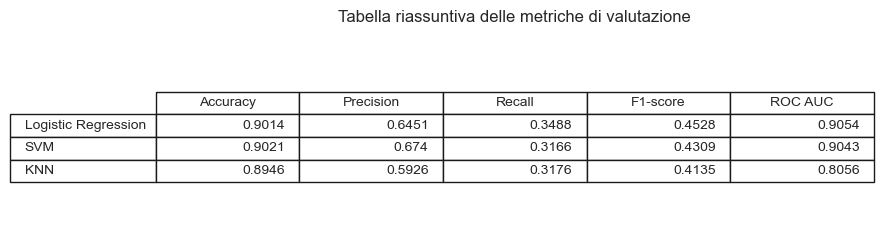

In [27]:
# 5.2 Tabella riassuntiva delle metriche
#results_table = results_df.copy().round(4)
#results_table.index.name = "Modello"

#print("Tabella riassuntiva delle metriche di valutazione:\n")
#print(results_table.to_string())

# 5.3 Salvataggio della tabella delle metriche come immagine
import matplotlib.pyplot as plt

results_table_img = results_df.copy().round(4)
results_table_img.index.name = "Modello"

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis('off')

table = ax.table(
    cellText=results_table_img.values,
    rowLabels=results_table_img.index,
    colLabels=results_table_img.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title("Tabella riassuntiva delle metriche di valutazione", pad=20)
plt.tight_layout()
plt.savefig("tabella_metriche_modelli.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Visualizzazione delle matrici di confusione e delle curve ROC

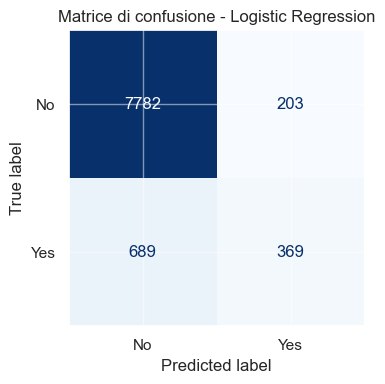

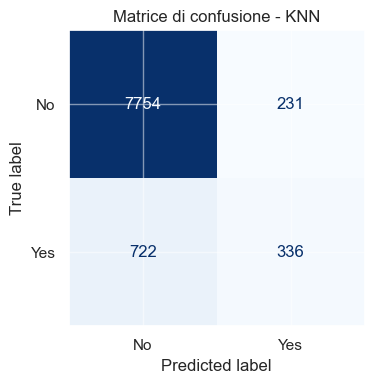

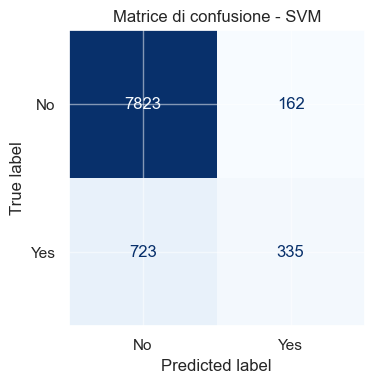

In [28]:
# 6.1 Matrici di confusione
for model_name in models.keys():
    cm = confusion_matrix(y_test, y_pred_dict[model_name])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)

    plt.title(f"Matrice di confusione - {model_name}")
    plt.tight_layout()
    plt.show()

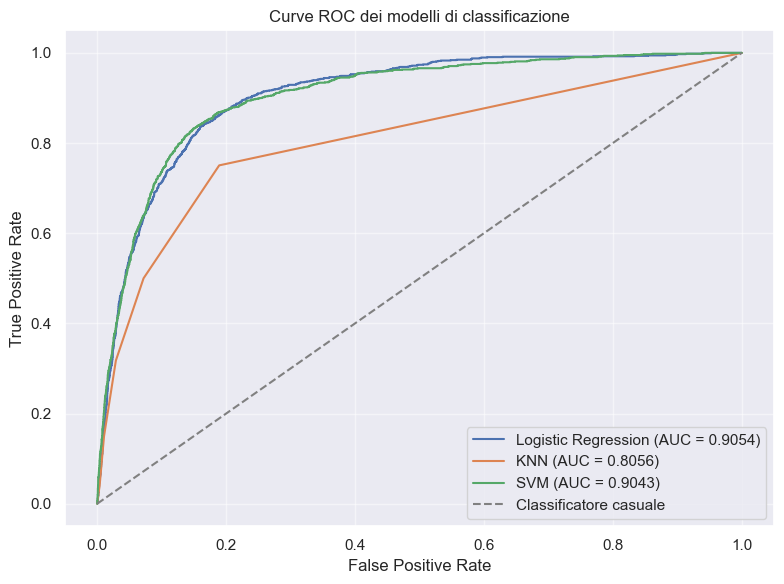

In [29]:
# 6.2 Curve ROC
plt.figure(figsize=(8, 6))

for model_name in models.keys():
    y_proba = y_proba_dict[model_name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})")

# Linea casuale
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificatore casuale")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curve ROC dei modelli di classificazione")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Explainability del modello tramite SHAP

In [30]:
# 7.1 Selezione del modello migliore
best_model_name = "Logistic Regression"
best_model = trained_models[best_model_name]

print(f"Modello selezionato per l'analisi SHAP: {best_model_name}")

Modello selezionato per l'analisi SHAP: Logistic Regression


In [31]:
# 7.2 Creazione del DataFrame del test set scalato con i nomi delle feature
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_encoded.columns, index=X_test.index)

In [32]:
# 7.3 Calcolo dei valori SHAP
explainer = shap.Explainer(best_model, X_train_scaled, feature_names=X_encoded.columns)
shap_values = explainer(X_test_scaled_df)

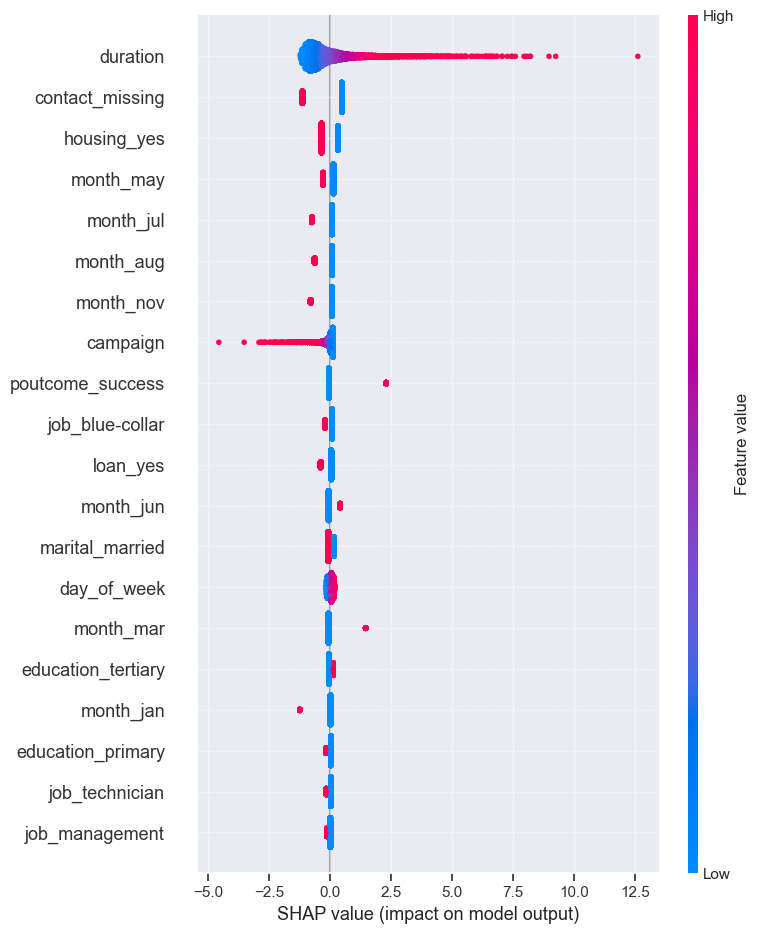

In [33]:
# 7.4 Summary plot SHAP
shap.summary_plot(shap_values, X_test_scaled_df, show=True)

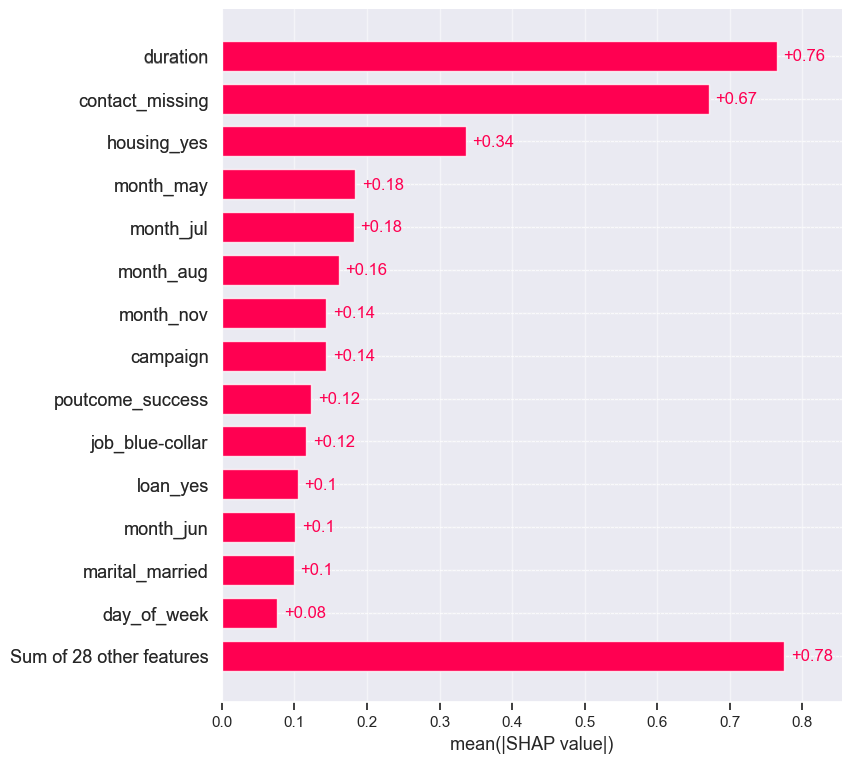

In [34]:
# 7.5 Bar plot dell'importanza globale delle feature
shap.plots.bar(shap_values, max_display=15)

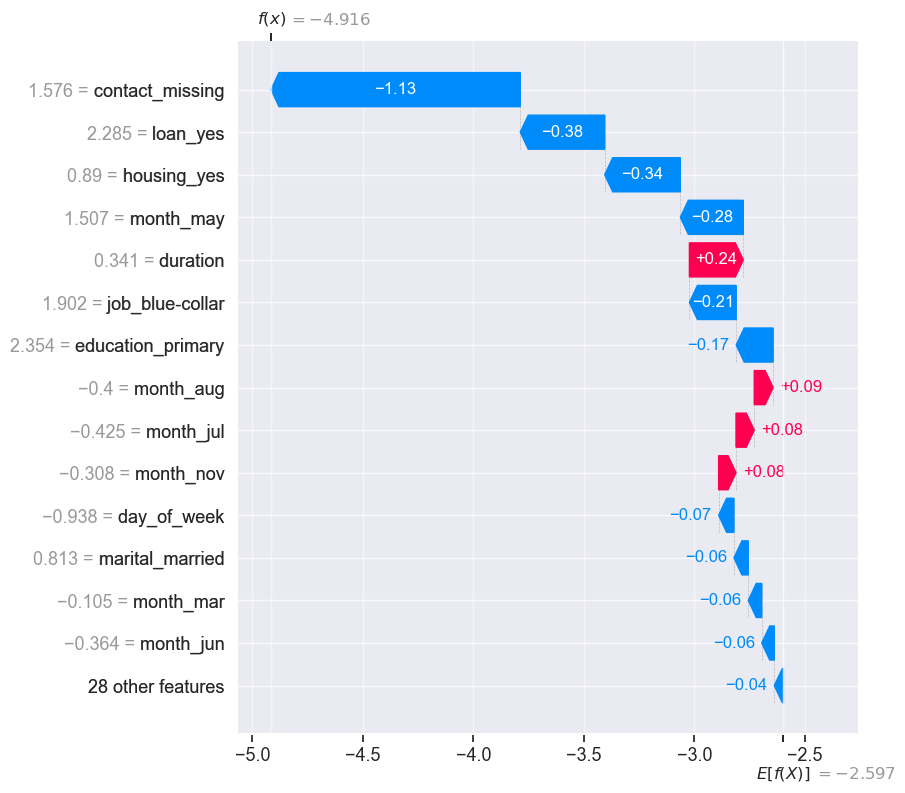

In [35]:
# 7.6 Waterfall plot di una singola osservazione
sample_index = 0
shap.plots.waterfall(shap_values[sample_index], max_display=15)

## 8. Approfondimento: cross-validation

In [40]:
# 8.1 Configurazione della Stratified K-Fold Cross Validation a 5 fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [42]:
# 8.2 Definizione delle pipeline per la cross-validation
cv_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(kernel="rbf", probability=True, random_state=42))
    ])
}

In [44]:
# 8.3 Metriche di valutazione per la cross-validation
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [45]:
# 8.4 Esecuzione della cross-validation
cv_results = {}

for model_name, model in cv_models.items():
    scores = cross_validate(
        model,
        X_encoded,
        y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=None,
        return_train_score=False
    )

    cv_results[model_name] = {
        "Accuracy mean": scores["test_accuracy"].mean(),
        "Accuracy std": scores["test_accuracy"].std(),
        "Precision mean": scores["test_precision"].mean(),
        "Recall mean": scores["test_recall"].mean(),
        "F1-score mean": scores["test_f1"].mean(),
        "ROC AUC mean": scores["test_roc_auc"].mean()
    }

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df = cv_results_df.sort_values(by="ROC AUC mean", ascending=False)

print("Risultati medi della cross-validation:\n")
print(cv_results_df.round(4).to_string())

Risultati medi della cross-validation:

                     Accuracy mean  Accuracy std  Precision mean  Recall mean  F1-score mean  ROC AUC mean
SVM                         0.9017        0.0025          0.6638       0.3258         0.4367        0.9083
Logistic Regression         0.9016        0.0018          0.6499       0.3460         0.4512        0.9065
KNN                         0.8934        0.0027          0.5794       0.3265         0.4173        0.8111


In [47]:
best_cv_model = cv_results_df["ROC AUC mean"].idxmax()
print(f"Miglior modello in cross-validation per ROC AUC media: {best_cv_model}")

Miglior modello in cross-validation per ROC AUC media: SVM
